# Phase 2 - Model 1: CNN + LSTM (Spatial-Temporal Model)

**Architecture**: Conv1D extracts local spatial features → LSTM captures temporal dependencies  
**Input**: Z (batch, 30, 64) — shared latent space from Feature Aligner  
**Output**: 5-class probabilities (Benign, BruteForce, DDoS, DoS, Infiltration)

In [9]:
import sys, os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent dir to path
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
from feature_alignment import (
    prepare_combined_dataset, FeatureAligner, create_dataloaders,
    DEVICE, LATENT_DIM, WINDOW_SIZE, NUM_CLASSES, UNIFIED_CLASSES
)

print(f"Device: {DEVICE}")


Device: cuda


## 1. Load & Prepare Data

In [10]:
# Load combined dataset (UQ + CIC)
data = prepare_combined_dataset()

uq_windows = data['uq']['windows']     # (N_uq, 30, 47)
uq_labels = data['uq']['labels']       # (N_uq,)
cic_windows = data['cic']['windows']    # (N_cic, 30, 78)
cic_labels = data['cic']['labels']      # (N_cic,)

uq_n_feat = data['uq']['n_features']   # 47
cic_n_feat = data['cic']['n_features']  # 78

print(f"UQ: {uq_windows.shape}, CIC: {cic_windows.shape}")
print(f"Classes: {data['classes']}")


[UQ] Loaded 1388150 flows, 47 features
[UQ] Label distribution:
Label
Benign          399999
DoS             300000
DDoS            300000
BruteForce      199999
Infiltration    188152
[UQ] Created 186005 windows of shape (186005, 30, 47)
[UQ] Feature dim: 47, Latent target: 64
[CIC] Loaded 237618 flows, 78 features
[CIC] Label distribution:
Label
Benign          100000
DoS              71588
DDoS             50000
BruteForce       15994
Infiltration        36
[CIC] Created 101615 windows of shape (101615, 30, 78)
[CIC] Feature dim: 78, Latent target: 64

=== Combined Dataset ===
UQ: 186005 windows, 47 features
CIC: 101615 windows, 78 features
Total: 287620 windows
UQ: (186005, 30, 47), CIC: (101615, 30, 78)
Classes: ['Benign', 'BruteForce', 'DDoS', 'DoS', 'Infiltration']


In [11]:
# Train/Val/Test split (70/15/15) — stratified
def split_data(windows, labels, test_size=0.15, val_size=0.15, seed=42):
    """Split into train/val/test with stratification."""
    # First split: train+val vs test
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        windows, labels, test_size=test_size, random_state=seed, stratify=labels
    )
    # Second split: train vs val
    val_ratio = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=val_ratio, random_state=seed, stratify=y_trainval
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

# Split UQ
uq_train, uq_val, uq_test, uq_y_train, uq_y_val, uq_y_test = split_data(uq_windows, uq_labels)
# Split CIC
cic_train, cic_val, cic_test, cic_y_train, cic_y_val, cic_y_test = split_data(cic_windows, cic_labels)

print(f"UQ  — Train: {len(uq_train)}, Val: {len(uq_val)}, Test: {len(uq_test)}")
print(f"CIC — Train: {len(cic_train)}, Val: {len(cic_val)}, Test: {len(cic_test)}")


UQ  — Train: 130203, Val: 27901, Test: 27901
CIC — Train: 71129, Val: 15243, Test: 15243


## 2. Define CNN+LSTM Model

**Architecture:**
- Conv1D Block: 64→128→64 (3 layers, kernel=3, BatchNorm+ReLU)
- LSTM: 64→128 (2 layers, dropout=0.3)  
- FC Head: 128→5 (softmax)

The FeatureAligner is integrated as the front-end: it maps raw features (UQ: 47-dim, CIC: 78-dim) into the shared 64-dim latent space before feeding into CNN+LSTM.

In [12]:
class CNN_LSTM(nn.Module):
    """
    CNN + LSTM Spatial-Temporal Model.
    Conv1D extracts local spatial patterns, LSTM captures temporal dependencies.
    """

    def __init__(self, latent_dim=LATENT_DIM, num_classes=NUM_CLASSES):
        super().__init__()

        # CNN Block: extract local spatial features from latent space
        # Input: (batch, latent_dim, time_steps) — Conv1d expects (B, C, L)
        self.cnn = nn.Sequential(
            nn.Conv1d(latent_dim, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Conv1d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )

        # LSTM Block: capture temporal dependencies
        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            dropout=0.3,
            bidirectional=False,
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, z):
        """
        Args:
            z: (batch, time_steps, latent_dim) — from FeatureAligner
        Returns:
            logits: (batch, num_classes)
        """
        # Conv1D expects (batch, channels, length)
        x = z.permute(0, 2, 1)         # (B, 64, 30)
        x = self.cnn(x)                 # (B, 64, 30)
        x = x.permute(0, 2, 1)         # (B, 30, 64)

        # LSTM
        lstm_out, (h_n, _) = self.lstm(x)  # lstm_out: (B, 30, 128)
        # Use last hidden state
        out = h_n[-1]                   # (B, 128)

        logits = self.classifier(out)   # (B, 5)
        return logits


class CNNLSTMWithAligner(nn.Module):
    """End-to-end model: FeatureAligner + CNN+LSTM."""

    def __init__(self, uq_input_dim, cic_input_dim):
        super().__init__()
        self.aligner = FeatureAligner(uq_input_dim, cic_input_dim)
        self.cnn_lstm = CNN_LSTM()

    def forward(self, x, dataset_type='uq'):
        z = self.aligner(x, dataset_type)  # (B, 30, 64)
        logits = self.cnn_lstm(z)           # (B, 5)
        return logits

    def predict_proba(self, x, dataset_type='uq'):
        """Return softmax probabilities."""
        logits = self.forward(x, dataset_type)
        return torch.softmax(logits, dim=1)


# Instantiate model
model = CNNLSTMWithAligner(uq_n_feat, cic_n_feat).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"CNN+LSTM Model: {total_params:,} params ({trainable_params:,} trainable)")
print(model)


CNN+LSTM Model: 364,869 params (364,869 trainable)
CNNLSTMWithAligner(
  (aligner): FeatureAligner(
    (uq_extractor): UQFeatureExtractor(
      (net): Sequential(
        (0): Linear(in_features=47, out_features=128, bias=True)
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.3, inplace=False)
        (4): Linear(in_features=128, out_features=64, bias=True)
        (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (6): ReLU()
      )
    )
    (cic_extractor): CICFeatureExtractor(
      (net): Sequential(
        (0): Linear(in_features=78, out_features=128, bias=True)
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.3, inplace=False)
        (4): Linear(in_features=128, out_features=64, bias=True)
        (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, 

## 3. Training Loop

In [13]:
def train_epoch(model, uq_loader, cic_loader, optimizer, criterion):
    """Train one epoch with round-robin between UQ and CIC batches."""
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0

    # Interleave UQ and CIC batches
    uq_iter = iter(uq_loader)
    cic_iter = iter(cic_loader)

    while True:
        # UQ batch
        if uq_iter is not None:
            try:
                x_uq, y_uq, _ = next(uq_iter)
                x_uq, y_uq = x_uq.to(DEVICE), y_uq.to(DEVICE)
                optimizer.zero_grad()
                logits = model(x_uq, 'uq')
                loss = criterion(logits, y_uq)
                loss.backward()
                optimizer.step()
                total_loss += loss.item() * len(y_uq)
                total_correct += (logits.argmax(1) == y_uq).sum().item()
                total_samples += len(y_uq)
            except StopIteration:
                uq_iter = None

        # CIC batch
        if cic_iter is not None:
            try:
                x_cic, y_cic, _ = next(cic_iter)
                x_cic, y_cic = x_cic.to(DEVICE), y_cic.to(DEVICE)
                optimizer.zero_grad()
                logits = model(x_cic, 'cic')
                loss = criterion(logits, y_cic)
                loss.backward()
                optimizer.step()
                total_loss += loss.item() * len(y_cic)
                total_correct += (logits.argmax(1) == y_cic).sum().item()
                total_samples += len(y_cic)
            except StopIteration:
                cic_iter = None

        if uq_iter is None and cic_iter is None:
            break

    return total_loss / total_samples, total_correct / total_samples


@torch.no_grad()
def evaluate(model, uq_loader, cic_loader, criterion):
    """Evaluate on both UQ and CIC validation sets."""
    model.eval()
    total_loss, total_correct, total_samples = 0, 0, 0

    for loader, dtype in [(uq_loader, 'uq'), (cic_loader, 'cic')]:
        for x, y, _ in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x, dtype)
            loss = criterion(logits, y)
            total_loss += loss.item() * len(y)
            total_correct += (logits.argmax(1) == y).sum().item()
            total_samples += len(y)

    return total_loss / total_samples, total_correct / total_samples


In [15]:
# Hyperparameters
EPOCHS = 50
BATCH_SIZE = 256
LR = 1e-3
PATIENCE = 7  # Early stopping patience

# Create DataLoaders
uq_train_loader = create_dataloaders(uq_train, uq_y_train, 'uq', BATCH_SIZE, shuffle=True)
uq_val_loader = create_dataloaders(uq_val, uq_y_val, 'uq', BATCH_SIZE, shuffle=False)
cic_train_loader = create_dataloaders(cic_train, cic_y_train, 'cic', BATCH_SIZE, shuffle=True)
cic_val_loader = create_dataloaders(cic_val, cic_y_val, 'cic', BATCH_SIZE, shuffle=False)

# Class weights for imbalanced data
all_train_labels = np.concatenate([uq_y_train, cic_y_train])
class_counts = np.bincount(all_train_labels, minlength=NUM_CLASSES)
class_weights = 1.0 / (class_counts + 1e-6)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)
print(f"Class weights: {class_weights}")

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

# Training loop with early stopping
best_val_loss = float('inf')
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, uq_train_loader, cic_train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, uq_val_loader, cic_val_loader, criterion)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.2e}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        os.makedirs('../Project/Model/Model_IRM', exist_ok=True)
        torch.save(model.state_dict(), '../Project/Model/Model_IRM/cnn_lstm_best.pth')
        print(f"  → Saved best model (val_loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

print(f"\nBest validation loss: {best_val_loss:.4f}")


Class weights: [0.2275553  1.10205534 0.9487298  1.48321543 1.23844412]
Epoch   1/50 | Train Loss: 0.2923 Acc: 0.8351 | Val Loss: 0.3768 Acc: 0.9154 | LR: 1.00e-03
  → Saved best model (val_loss: 0.3768)
Epoch   2/50 | Train Loss: 0.1649 Acc: 0.9235 | Val Loss: 0.2752 Acc: 0.9069 | LR: 1.00e-03
  → Saved best model (val_loss: 0.2752)
Epoch   3/50 | Train Loss: 0.1410 Acc: 0.9341 | Val Loss: 0.1578 Acc: 0.9494 | LR: 1.00e-03
  → Saved best model (val_loss: 0.1578)
Epoch   4/50 | Train Loss: 0.1321 Acc: 0.9369 | Val Loss: 0.2653 Acc: 0.9172 | LR: 1.00e-03
Epoch   5/50 | Train Loss: 0.1207 Acc: 0.9410 | Val Loss: 0.1879 Acc: 0.9383 | LR: 1.00e-03
Epoch   6/50 | Train Loss: 0.1162 Acc: 0.9429 | Val Loss: 0.1479 Acc: 0.9437 | LR: 1.00e-03
  → Saved best model (val_loss: 0.1479)
Epoch   7/50 | Train Loss: 0.1141 Acc: 0.9422 | Val Loss: 1.0407 Acc: 0.7858 | LR: 1.00e-03
Epoch   8/50 | Train Loss: 0.1112 Acc: 0.9431 | Val Loss: 0.1431 Acc: 0.9318 | LR: 1.00e-03
  → Saved best model (val_loss: 

## 4. Evaluation

In [ ]:
# Load best model
model.load_state_dict(torch.load('../Project/Model/Model_IRM/cnn_lstm_best.pth', weights_only=True))
model.eval()

# Test evaluation
uq_test_loader = create_dataloaders(uq_test, uq_y_test, 'uq', BATCH_SIZE, shuffle=False)
cic_test_loader = create_dataloaders(cic_test, cic_y_test, 'cic', BATCH_SIZE, shuffle=False)

all_preds, all_labels = [], []
with torch.no_grad():
    for loader, dtype in [(uq_test_loader, 'uq'), (cic_test_loader, 'cic')]:
        for x, y, _ in loader:
            x = x.to(DEVICE)
            logits = model(x, dtype)
            preds = logits.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print("=== CNN+LSTM Test Results ===\n")
print(classification_report(all_labels, all_preds, target_names=UNIFIED_CLASSES, digits=4))


=== CNN+LSTM Test Results ===

              precision    recall  f1-score   support

      Benign     0.9089    0.8099    0.8566     24191
  BruteForce     0.9766    0.9608    0.9686      4995
        DDoS     0.9786    0.7094    0.8225      5802
         DoS     0.4861    0.9588    0.6451      3711
Infiltration     0.7870    0.9118    0.8448      4445

    accuracy                         0.8372     43144
   macro avg     0.8275    0.8701    0.8275     43144
weighted avg     0.8772    0.8372    0.8456     43144



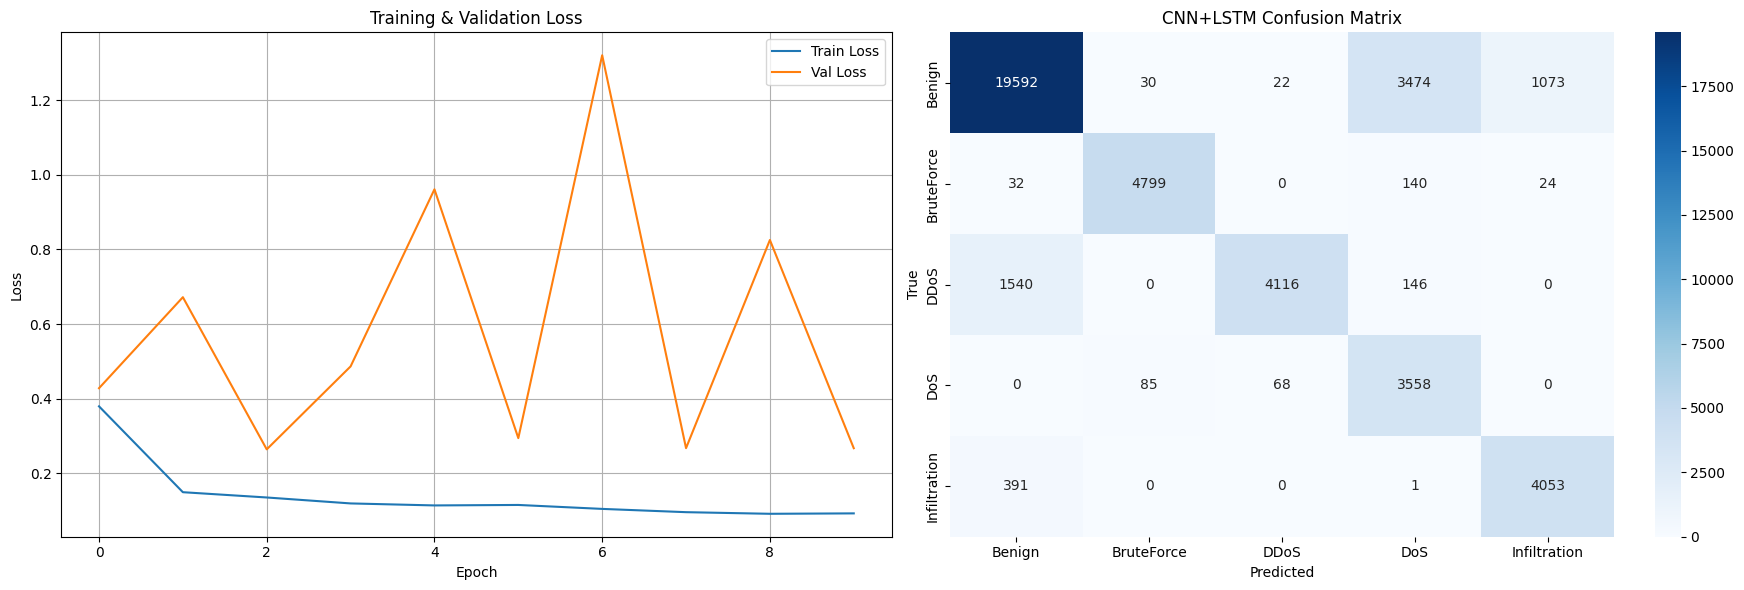

Results saved.


In [ ]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Training curves
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=UNIFIED_CLASSES, yticklabels=UNIFIED_CLASSES, ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_title('CNN+LSTM Confusion Matrix')

plt.tight_layout()
plt.show()
print("Results saved.")
